In [5]:
import openai
import re
import httpx
import os
from dotenv import load_dotenv

_ = load_dotenv()
from openai import OpenAI
import os
from urllib.request import urlopen, Request
import base64
from pathlib import Path
from dotenv import load_dotenv

# Add references
from openai import OpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider

In [6]:
# Get configuration settings 
load_dotenv()
openai_endpoint = os.getenv("ENDPOINT")
model_deployment =  os.getenv("MODEL_DEPLOYMENT")


# Create an OpenAI client
credential = DefaultAzureCredential()
token_provider = get_bearer_token_provider(credential, "https://ai.azure.com/.default")
client = OpenAI(
    base_url=openai_endpoint,
    api_key=token_provider()
) 
chat_completion = client.chat.completions.create(
    model=model_deployment,
    messages=[{"role": "user", "content": "Hello world"}]
) 
print(chat_completion.choices[0].message.content)                                


Hello! How can I help you today — answer a question, write or review code, draft something, or something else?


In [7]:
from dotenv import load_dotenv
_ = load_dotenv()

In [8]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

C:\Users\a855099\AppData\Local\Temp\ipykernel_13708\2233616850.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [9]:
tool = TavilySearchResults(max_results=4,
                           tavily_api_key="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") #increased number of results
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


C:\Users\a855099\AppData\Local\Temp\ipykernel_13708\1713634794.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4,


In [10]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [11]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [18]:
load_dotenv()
openai_endpoint = os.getenv("ENDPOINT")
model_deployment =  os.getenv("MODEL_DEPLOYMENT")


# Create an OpenAI client
credential = DefaultAzureCredential()
token_provider = get_bearer_token_provider(credential, "https://ai.azure.com/.default")

prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(model=model_deployment,
                   api_key=token_provider,
                   base_url=openai_endpoint)  #reduce inference cost
abot = Agent(model, [tool], system=prompt)

In [2]:
 pip install pygraphviz

Note: you may need to restart the kernel to use updated packages.


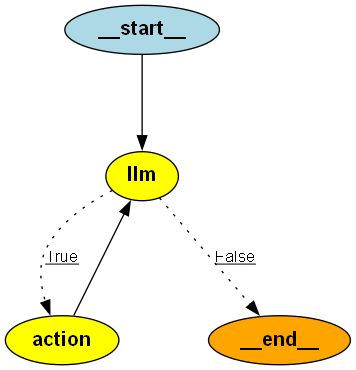

In [19]:
from IPython.display import Image

Image(abot.graph.get_graph().draw_png())

In [20]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'San Francisco current weather'}, 'id': 'call_PqacL8XOKKErKE6GCRfKhz5m', 'type': 'tool_call'}
Back to the model!


In [21]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 94, 'prompt_tokens': 235, 'total_tokens': 329, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 7, 'engine_ttft_ms': 36, 'engine_ttlt_ms': 771, 'pre_inference_ms': 337, 'service_tbt_ms': 6, 'service_ttft_ms': 674, 'service_ttlt_ms': 1395, 'user_visible_ttft_ms': 337}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-ERJW94P6jTzOCkr4TqWlA0WuDzIY6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0cef5-6780-7d31-8c27-893199ff0f40-0', tool_

In [22]:
result['messages'][-1].content

'Right now in San Francisco (per the National Weather Service): about 56°F (13°C), patchy fog, humidity ~100%, dew point 56°F. Forecast: fog this morning then sunny with a high near 77°F; tonight mostly clear with a low near 58°F. (NWS last update ~6:43 AM PDT, Sep 23, 2026.)\n\nWant an hourly breakdown, a 7‑day forecast, or weather for a specific neighborhood?'

In [23]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'San Francisco weather current temperature SF weather now'}, 'id': 'call_2yZxh4KYNjzMIvYSPXzkbs3b', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles weather current temperature LA weather now'}, 'id': 'call_5qIF4HyHsvsNvVIqM5f5fNyE', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'San Francisco CA current weather now National Weather Service (NWS) San Francisco current conditions 94102'}, 'id': 'call_Qj4gpNdDA6iUBmB7dVMyHcH1', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Los Angeles CA current weather now National Weather Service (NWS) Los Angeles current conditions downtown LAX current temperature'}, 'id': 'call_8Ut0bH58WUGD66IkmyRKnzkd', 'type': 'tool_call'}
Back to the model!


In [24]:
result['messages'][-1].content

'Do you mean San Francisco and Los Angeles? If so — current conditions (from the National Weather Service):\n\n- San Francisco (downtown area / 37.77°N): 56°F (13°C), patchy fog now then becoming sunny. Today’s high about 77°F; tonight low near 58°F. (NWS point forecast / last update this morning)\n\n- Los Angeles (LAX area): 67°F (19°C), mostly clear, calm winds. Expect a warm day — highs in the upper‑70s to low‑80s with a shallow marine layer mostly confined to the immediate coast. (KLAX obs / NWS forecast)\n\nWant hourly forecasts, a specific neighborhood (e.g., SF Marina, downtown LA, Hollywood), or an outlook for the next few days?'

In [26]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.

query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatOpenAI(model=model_deployment,
                   api_key=token_provider,
                   base_url=openai_endpoint)  # requires more advanced model
abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Who won Super Bowl 2024 Super Bowl LVIII winner Kansas City Chiefs 2024 score overtime 25-22 source'}, 'id': 'call_nXAYeGlquHPVAjcr4I8zns1Y', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Missouri GDP 2023 nominal gross domestic product Missouri 2023 total GDP U.S. Bureau of Economic Analysis 2023 Missouri GDP 2023 value'}, 'id': 'call_uj5Uu5mQqAJIcTCBujNmNJ2F', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': "Kansas City Chiefs headquarters location state headquarters Kansas City Chiefs team headquarters address 'Kansas City, Missouri' official site"}, 'id': 'call_EzGwn2jh6aT2wDkHC3h47um0', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': "BEA Missouri GDP 2023 nominal 'Gross Domestic Product by State' Missouri 2023 GDP BEA 'Missouri GDP 2023' va

In [27]:
print(result['messages'][-1].content)

- Who won the Super Bowl in 2024?
  - The Kansas City Chiefs. (Super Bowl LVIII, Feb 11, 2024.)

- In what state is the winning team’s headquarters located?
  - Missouri (the Chiefs are headquartered in Kansas City, Missouri).

- What is the GDP of that state?
  - Missouri’s 2023 current‑dollar (nominal) GDP was about $430.4 billion (BEA, Gross Domestic Product by State, preliminary 2023 estimates).
